In [1]:
"""
There appears to be a bifurcation in the I-O plots for a given set of autapse parameters

- Can estimate this transition based on discontinuities of the derivative.

F_steady: -> negative area under the 1st derivative plot is non-zero for the select autapse parameters
F_instant -> There is a bifurcation where the neuron becomes extra sensitive to inputs with an autapse.
        Here the slope at the start of the curve is very steep!


"""


#from batchAQUA_general import batchAQUA
#from AQUA_general import AQUA
#from stimulus import *
from aqua.batchAQUA_general import *
from aqua.AQUA_general import *
from aqua.stimulus import *


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
import pickle
import random


from simulation import get_F

In [2]:
# initial tests on RS_int
SAVE = False
neuron = "RS_intHD_test"
out_dir = f".//{neuron}//"

filename = f"{neuron}.pickle"
with open(filename, 'rb') as file:
    df = pickle.load(file)

print(df.keys())
print(df["F_steady"])


Index(['e', 'f', 'tau', 'I_h', 'F_instant', 'F_steady', 'autapse current',
       'autapse delay'],
      dtype='object')
0             NaN
1             NaN
2             NaN
3             NaN
4             NaN
          ...    
1095    95.238095
1096    94.339623
1097    93.457944
1098    91.743119
1099    90.909091
Name: F_steady, Length: 50100, dtype: float64


[0.         0.1        0.14444444 0.18888889 0.23333333 0.27777778
 0.32222222 0.36666667 0.41111111 0.45555556 0.5       ]
[  0.          50.          72.22222222  94.44444444 116.66666667
 138.88888889 161.11111111 183.33333333 205.55555556 227.77777778
 250.        ]


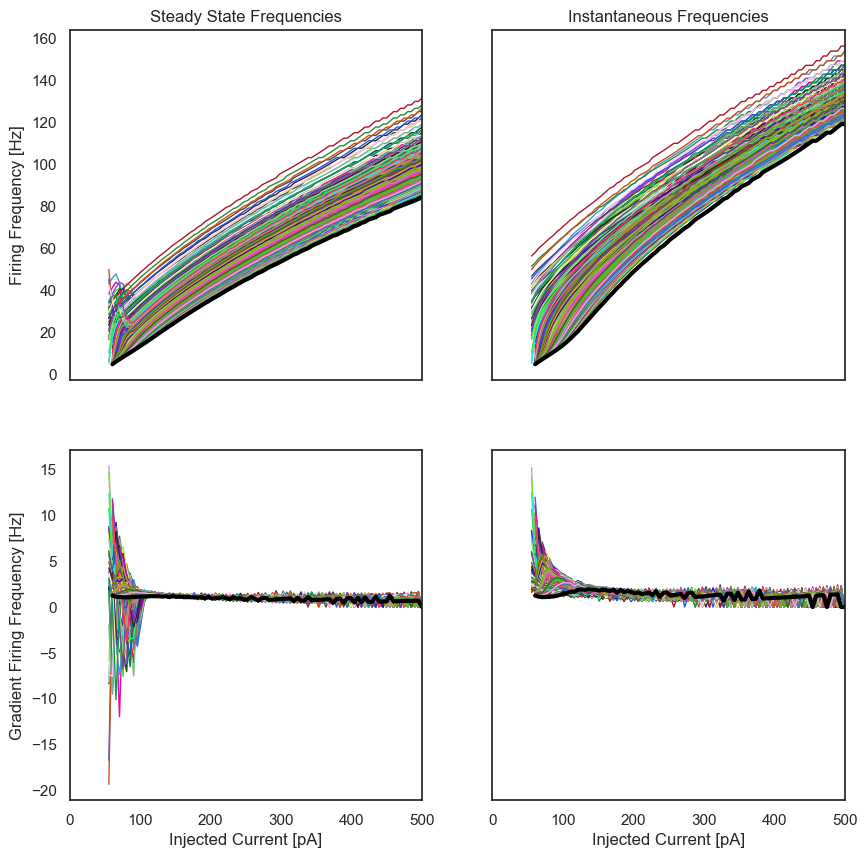

In [3]:
### EXTRACT relevant data

e_vals = df["e"].unique()
f_vals = df["f"].unique()
tau_vals = df["tau"].unique()

print(e_vals)
print(f_vals)

# Get plotting data in I-O curves
fig, ax = plt.subplots(2, 2, figsize = (10, 10), sharex = True, sharey = 'row')

for e in np.flip(e_vals):
    for f in np.flip(f_vals):
        for tau in np.flip(tau_vals):
            # colours for plotting
            if e == 0.0 and f == 0.0 and tau == 0.0:
                colour = (0., 0., 0.)
                linewidth = 3
            else:
                colour = tuple(np.random.rand(3))   # colour for individual neurons
                linewidth = 1
        
            # get relevant neuron with autapse parameters
            sub_df = df[(df["e"] == e) & (df["f"] == f) & (df["tau"] == tau)].copy()
            if sub_df.empty:
                continue

            sub_df.sort_values(by = ["I_h"])

            I_h = np.array(sub_df["I_h"])
            F_steady = np.array(sub_df["F_steady"])
            grad_f_steady = np.ediff1d(F_steady, to_end = 0.0)
            F_instant = np.array(sub_df["F_instant"])
            grad_f_instant = np.ediff1d(F_instant, to_end = 0.0)

            ax[0, 0].plot(I_h, F_steady, c = colour, linewidth = linewidth)
            ax[0, 1].plot(I_h, F_instant, c = colour, linewidth = linewidth)
            ax[1, 0].plot(I_h, grad_f_steady, c = colour, linewidth = linewidth)
            ax[1, 1].plot(I_h, grad_f_instant, c = colour, linewidth = linewidth)


ax[0, 0].set_xlim((np.min(I_h), np.max(I_h)))
ax[0, 0].set_ylabel("Firing Frequency [Hz]")
ax[1, 0].set_ylabel("Gradient Firing Frequency [Hz]")
ax[1, 0].set_xlabel("Injected Current [pA]")
ax[1, 1].set_xlabel("Injected Current [pA]")

ax[0, 0].set_title("Steady State Frequencies")
ax[0, 1].set_title("Instantaneous Frequencies")

if SAVE: plt.savefig(out_dir + "I-O_gain_and_derivatives.png")


##### Plot where the bump on steady state FI and sharp rise in the instant frequencies occur

In [4]:
### EXTRACT relevant data

e_vals = df["e"].unique()
e_vals = np.delete(e_vals, 0)
f_vals = df["f"].unique()
f_vals = np.delete(f_vals, 0)
tau_vals = df["tau"].unique()


N_neurons = 1 + len(e_vals)*len(f_vals)*len(tau_vals)
print(f"N_neurons: {N_neurons}")


autapse_current = np.zeros(N_neurons)
f_value = np.zeros(N_neurons)
e_value = np.zeros(N_neurons)
autapse_delay = np.zeros(N_neurons)
instant_gradient = np.zeros(N_neurons)
area_steady = np.zeros(N_neurons)

count = 0
for e in np.flip(e_vals):
    for f in np.flip(f_vals):
        for tau in np.flip(tau_vals):
        
            # get relevant neuron with autapse parameters
            sub_df = df[(df["e"] == e) & (df["f"] == f) & (df["tau"] == tau)].copy()
            if sub_df.empty:
                continue
            else:
                sub_df.sort_values(by = ["I_h"])

                F_steady = np.array(sub_df["F_steady"])
                grad_f_steady = np.ediff1d(F_steady, to_end = 0.0)
                F_instant = np.array(sub_df["F_instant"])
                grad_f_instant = np.ediff1d(F_instant, to_end = 0.0)
                if count == 0:
                    print(grad_f_instant)

                autapse_current[count] = sub_df["autapse current"].unique()[0]
                f_value[count] = sub_df["f"].unique()[0]
                e_value[count] = sub_df["e"].unique()[0]
                autapse_delay[count] = sub_df["autapse delay"].unique()[0]
                instant_gradient[count] = np.max(grad_f_instant[~np.isnan(grad_f_instant)])  # first non-nan element
                area_steady[count] = np.abs(np.sum(grad_f_steady[(~np.isnan(grad_f_steady)) & (grad_f_steady < 0.)]))     # essentially the area under the steady gradient curve

                count += 1

autapse_current = np.nan_to_num(autapse_current, 0.)
autapse_delay = np.nan_to_num(autapse_delay, 0.)
sort_idx = np.argsort(autapse_current)

autapse_current = np.round(autapse_current, 0)
autapse_delay = np.round(autapse_delay, 2)
f_value = np.round(f_value, 1)
e_value = np.round(e_value, 2)

dict = {"autapse current": autapse_current[sort_idx],
        "f value": f_value[sort_idx],
        "e value": e_value[sort_idx],
        "autapse delay": autapse_delay[sort_idx],
        "instant gradient": instant_gradient[sort_idx],
        "area steady": area_steady[sort_idx]}
new_df = pd.DataFrame(dict)

N_neurons: 501
[       nan        nan        nan        nan        nan        nan
        nan        nan        nan        nan        nan        nan
 1.34543628 1.27901435 1.30982254 1.49236508 1.79978906 2.23368736
 2.76759811 3.06818795 3.18806831 3.09857101 2.90779979 2.49105067
 2.71869155 2.40044471 2.29779412 2.25981405 1.96772924 1.95882549
 1.92094254 1.84979652 2.00080032 1.61117078 1.71624714 1.83194919
 1.62369293 1.36812943 1.80401212 1.52439024 1.6025641  1.25691302
 1.30718954 1.36054422 1.41723356 1.47754137 1.5417823  1.06564365
 1.09745391 1.70901219 1.18350198 1.22077764 1.25984252 1.30081301
 1.34381509 0.68870523 1.41242938 1.46113384 0.74962519 1.53905348
 0.79013906 0.8043758  1.65302918 0.84947333 0.86535133 1.78015131
 0.91575092 0.93353249 0.95183705 0.9706853  0.99009901 1.01010101
 1.03071532 1.05196718 1.07388316 1.09649123 1.11982083 1.143903
 1.16877045 0.         1.19445772 1.22100122 1.24843945 1.27681307
 0.         1.3061651  1.33654103 1.36798906 0.  

WARNING    C:\Users\liamm\AppData\Local\Temp\ipykernel_32132\2702040677.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 45, ha = 'right')
 [py.warnings]
WARNING    C:\Users\liamm\AppData\Local\Temp\ipykernel_32132\2702040677.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation = 45, ha = 'right')
 [py.warnings]


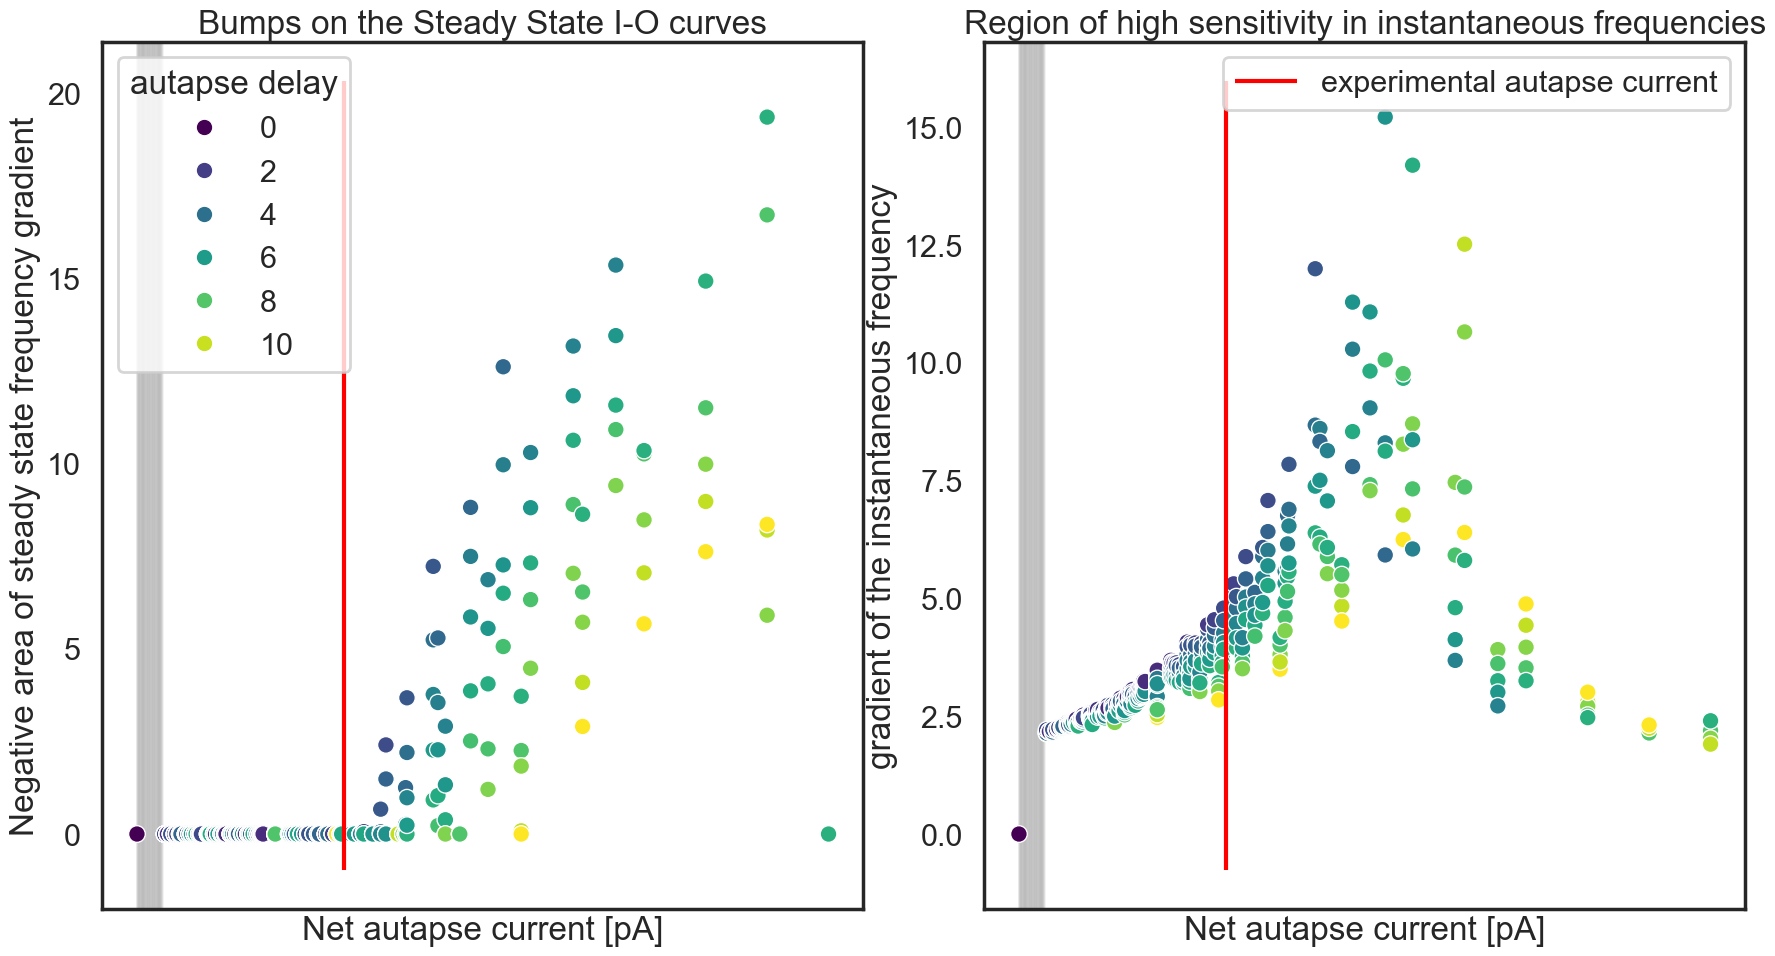

In [ ]:
"""
Plot of derivative metrics as a function of some autapse parameter metrics (net current and delay)

"""

fig, ax = plt.subplots(1, 2, figsize = (18, 10))
plt.tight_layout()

sns.scatterplot(data = new_df, x = "autapse current", y = "area steady", hue = "autapse delay", palette = 'viridis', ax = ax[0])
sns.scatterplot(data = new_df, x = "autapse current", y = "instant gradient", hue = "autapse delay", palette = 'viridis', ax = ax[1], legend = False)
#sns.scatterplot(data = new_df, x = "autapse current", y = "area steady", ax = ax[0], width = 1., legend = False, errorbar = None)
#sns.scatterplot(data = new_df, x = "autapse current", y = "instant gradient", ax = ax[1], width = 1., legend = False, errorbar = None)

# create a legend for the whole figure
#handles, labels = ax[0].get_legend_handles_labels()     # get legend from ax[0]
#ax[0].get_legend().remove()                             # delete legend data
#fig.legend(handles, labels, title='Autapse Delay', loc='center right', 
#           bbox_to_anchor=(1.15, 0.5))

# Loop through the number of categories on your x-axis
for i in range(len(new_df["autapse current"].unique())):
    if i % 2 == 0:
        ax[0].axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)
        ax[1].axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)

ax[0].set_ylabel("Negative area of steady state frequency gradient")
ax[1].set_ylabel("gradient of the instantaneous frequency")

ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 45, ha = 'right')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation = 45, ha = 'right')

'''
# add a red line at the biological autapse
labels = np.array([float(t.get_text()) for t in ax[0].get_xticklabels()])
print(labels)
aut_exp = 750   # (f/e)
x_pos = np.argmin(np.abs(labels - aut_exp))

ax[0].vlines(x_pos, ax[0].get_ylim()[0], ax[0].get_ylim()[1], color = 'red', label = 'experimental autapse current')
ax[1].vlines(x_pos, ax[1].get_ylim()[0], ax[1].get_ylim()[1], color = 'red', label = 'experimental autapse current')
'''
experimental_current = 150/0.2  # 750
ax[0].vlines(experimental_current, ax[0].get_ylim()[0], ax[0].get_ylim()[1], color = 'red', label = 'experimental autapse current')
ax[1].vlines(experimental_current, ax[1].get_ylim()[0], ax[1].get_ylim()[1], color = 'red', label = 'experimental autapse current')


#only show every 10th tick label
tick_spacing = 10
positions = range(0, len(df), tick_spacing)
for ind, label in enumerate(ax[0].get_xticklabels()):
    if ind % 10 == 0:  # Keep the 0th, 10th, 20th...
        label.set_visible(True)
    else:
        label.set_visible(False)

for ind, label in enumerate(ax[1].get_xticklabels()):
    if ind % 10 == 0:  # Keep the 0th, 10th, 20th...
        label.set_visible(True)
    else:
        label.set_visible(False)


ax[0].set_title("Bumps on the Steady State I-O curves")
ax[1].set_title("Region of high sensitivity in instantaneous frequencies")
ax[0].set_xlabel("Net autapse current [pA]")
ax[1].set_xlabel("Net autapse current [pA]")

plt.legend()
sns.move_legend(ax[0], 'upper left')
sns.set_context('poster')

if SAVE: plt.savefig(out_dir + "I-O_scatter_net-current.png")
#plt.savefig(".//poster//I-O_scatter_net-current.png")
plt.show()


WARNING    C:\Users\liamm\AppData\Local\Temp\ipykernel_32132\51485548.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 45, ha = 'center')
 [py.warnings]
WARNING    C:\Users\liamm\AppData\Local\Temp\ipykernel_32132\51485548.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation = 45, ha = 'center')
 [py.warnings]


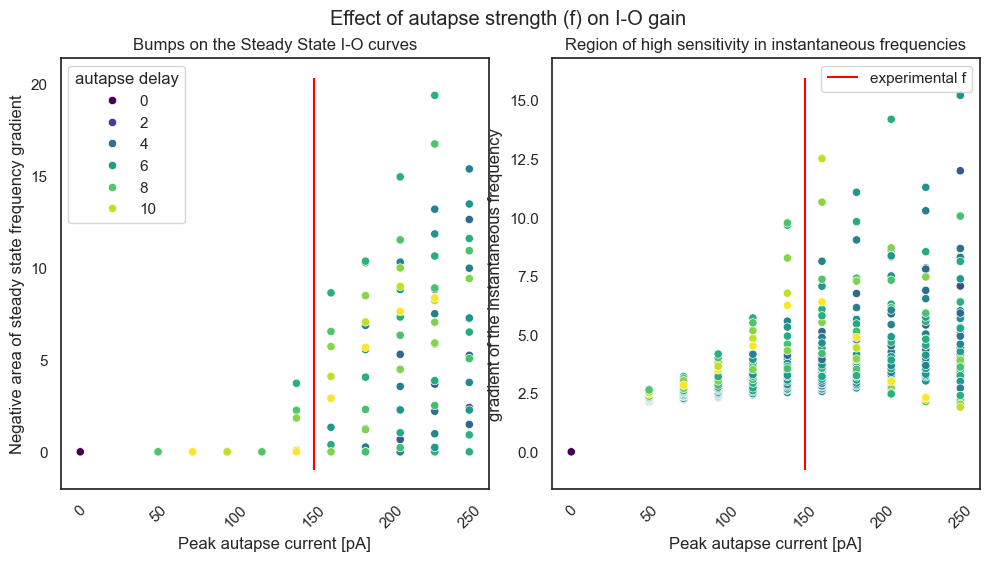

In [6]:
"""
Plot of derivative metrics as a function of autapse strength

"""

fig, ax = plt.subplots(1, 2, figsize = (10, 5))
plt.tight_layout()

sns.scatterplot(data = new_df, x = "f value", y = "area steady", hue = "autapse delay", palette = 'viridis', ax = ax[0])
sns.scatterplot(data = new_df, x = "f value", y = "instant gradient", hue = "autapse delay", palette = 'viridis', ax = ax[1], legend = False)
#sns.barplot(data = new_df, x = "f value", y = "area steady", ax = ax[0], width = 1.)
#sns.barplot(data = new_df, x = "f value", y = "instant gradient", ax = ax[1], width = 1., legend = False)

"""
# create a legend for the whole figure
handles, labels = ax[0].get_legend_handles_labels()     # get legend from ax[0]
ax[0].get_legend().remove()                             # delete legend data
fig.legend(handles, labels, title='Autapse Delay', loc='center right', 
           bbox_to_anchor=(1.15, 0.5))
"""

'''
# Loop through the number of categories on your x-axis
for i in range(len(new_df["f value"].unique())):
    if i % 2 == 0:
        ax[0].axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)
        ax[1].axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)
'''
ax[0].set_ylabel("Negative area of steady state frequency gradient")
ax[1].set_ylabel("gradient of the instantaneous frequency")

ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 45, ha = 'center')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation = 45, ha = 'center')

''' place a vertical red line at the experimental value
labels = np.array([float(t.get_text()) for t in ax[0].get_xticklabels()])
diff = labels[2] - labels[1] 
f_exp = 150
x_pos = (f_exp-50)/diff + 1
'''
f_experiment = 150
ax[0].vlines(f_experiment, ax[0].get_ylim()[0], ax[0].get_ylim()[1], color = 'red', label = 'experimental f')
ax[1].vlines(f_experiment, ax[1].get_ylim()[0], ax[1].get_ylim()[1], color = 'red', label = 'experimental f')
plt.legend()

fig.suptitle("Effect of autapse strength (f) on I-O gain", y = 1.05)

ax[0].set_title("Bumps on the Steady State I-O curves")
ax[1].set_title("Region of high sensitivity in instantaneous frequencies")
ax[0].set_xlabel("Peak autapse current [pA]")
ax[1].set_xlabel("Peak autapse current [pA]")

if SAVE: plt.savefig(out_dir + "I-O_scatter_f.png")
plt.show()

WARNING    C:\Users\liamm\AppData\Local\Temp\ipykernel_32132\3134488669.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 45, ha = 'center')
 [py.warnings]
WARNING    C:\Users\liamm\AppData\Local\Temp\ipykernel_32132\3134488669.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation = 45, ha = 'center')
 [py.warnings]


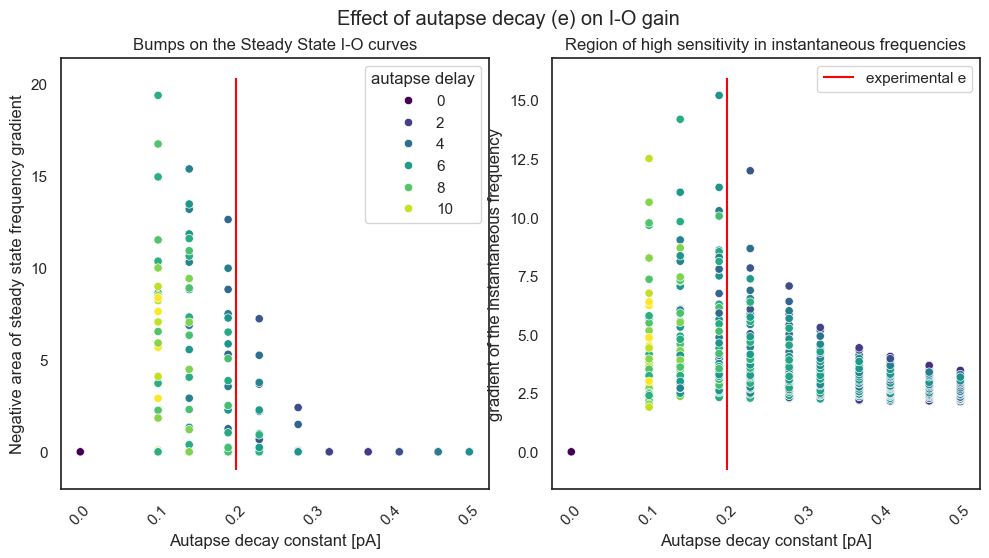

In [7]:
"""
Plot of derivative metrics as a function of autapse strength

"""

fig, ax = plt.subplots(1, 2, figsize = (10, 5))
plt.tight_layout()

sns.scatterplot(data = new_df, x = "e value", y = "area steady", hue = "autapse delay", palette = 'viridis', ax = ax[0])
sns.scatterplot(data = new_df, x = "e value", y = "instant gradient", hue = "autapse delay", palette = 'viridis', ax = ax[1], legend = False)
#sns.barplot(data = new_df, x = "e value", y = "area steady", ax = ax[0], width = 1.)
#sns.barplot(data = new_df, x = "e value", y = "instant gradient", ax = ax[1], width = 1., legend = False)

"""
# create a legend for the whole figure
handles, labels = ax[0].get_legend_handles_labels()     # get legend from ax[0]
ax[0].get_legend().remove()                             # delete legend data
fig.legend(handles, labels, title='Autapse Delay', loc='center right', 
           bbox_to_anchor=(1.15, 0.5))
"""

'''     
# Loop through the number of categories on your x-axis
for i in range(len(new_df["e value"].unique())):
    if i % 2 == 0:
        ax[0].axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)
        ax[1].axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)
'''

ax[0].set_ylabel("Negative area of steady state frequency gradient")
ax[1].set_ylabel("gradient of the instantaneous frequency")

ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 45, ha = 'center')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation = 45, ha = 'center')

''' place vertical line at the experimental value
labels = np.array([float(t.get_text()) for t in ax[0].get_xticklabels()])
diff = labels[2] - labels[1] 
e_exp = 0.2
x_pos = (e_exp-0.1)/diff + 1
# values for the next plot
N_e = len(labels)
e_frac = x_pos/N_e     # the fractional position of the red line from 0->1
print(e_frac)
'''

e_experiment = 0.2
ax[0].vlines(e_experiment, ax[0].get_ylim()[0], ax[0].get_ylim()[1], color = 'red', label = 'experimental e')
ax[1].vlines(e_experiment, ax[1].get_ylim()[0], ax[1].get_ylim()[1], color = 'red', label = 'experimental e')
plt.legend()


fig.suptitle("Effect of autapse decay (e) on I-O gain", y = 1.05)

ax[0].set_title("Bumps on the Steady State I-O curves")
ax[1].set_title("Region of high sensitivity in instantaneous frequencies")
ax[0].set_xlabel("Autapse decay constant [pA]")
ax[1].set_xlabel("Autapse decay constant [pA]")

if SAVE: plt.savefig(out_dir + "I-O_scatter_e.png")

plt.show()

WARNING    C:\Users\liamm\AppData\Local\Temp\ipykernel_32132\2162847635.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 45, ha = 'center')
 [py.warnings]
WARNING    C:\Users\liamm\AppData\Local\Temp\ipykernel_32132\2162847635.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation = 45, ha = 'center')
 [py.warnings]


NameError: name 'e_frac' is not defined

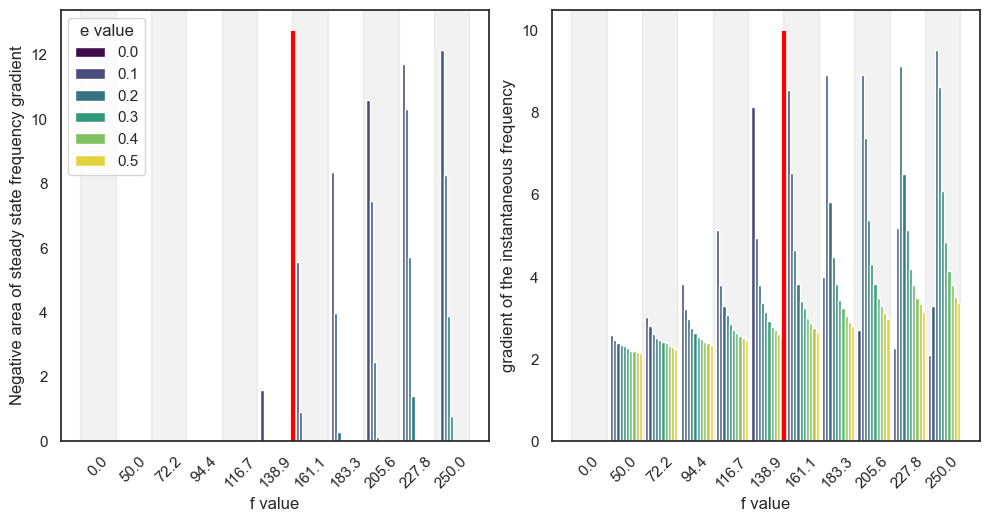

In [8]:
"""
Plot of derivative metrics as a function of autapse strength

"""

fig, ax = plt.subplots(1, 2, figsize = (10, 5))
plt.tight_layout()

#sns.barplot(data = new_df, x = "f value", y = "area steady", hue = "autapse delay", palette = 'viridis', ax = ax[0], width = 1.)
#sns.barplot(data = new_df, x = "f value", y = "instant gradient", hue = "autapse delay", palette = 'viridis', ax = ax[1], width = 1., legend = False)
sns.barplot(data = new_df, x = "f value", y = "area steady", hue = "e value", palette = "viridis", ax = ax[0], width = 1., errorbar = None)
sns.barplot(data = new_df, x = "f value", y = "instant gradient", hue = "e value", palette = "viridis", ax = ax[1], width = 1., legend = False, errorbar = None)

"""
# create a legend for the whole figure
handles, labels = ax[0].get_legend_handles_labels()     # get legend from ax[0]
ax[0].get_legend().remove()                             # delete legend data
fig.legend(handles, labels, title='Autapse Delay', loc='center right', 
           bbox_to_anchor=(1.15, 0.5))
"""
           
# Loop through the number of categories on your x-axis
for i in range(len(new_df["f value"].unique())):
    if i % 2 == 0:
        ax[0].axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)
        ax[1].axvspan(i - 0.5, i + 0.5, color='gray', alpha=0.1, zorder=0)

ax[0].set_ylabel("Negative area of steady state frequency gradient")
ax[1].set_ylabel("gradient of the instantaneous frequency")

ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation = 45, ha = 'center')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation = 45, ha = 'center')

# add a red line at the experimental f value
labels = np.array([float(t.get_text()) for t in ax[0].get_xticklabels()])
diff = labels[2] - labels[1] 
f_exp = 150
x_pos = (f_exp-50)/diff + 1

ax[0].vlines(x_pos, ax[0].get_ylim()[0], ax[0].get_ylim()[1], color = 'red', linewidth = 3, label = 'experimental f')
ax[1].vlines(x_pos, ax[1].get_ylim()[0], ax[1].get_ylim()[1], color = 'red', linewidth = 3, label = 'experimental f')

# add lighter lines for every experimental e position
e_pos = e_frac + np.arange(0.5, N_e)
ax[0].vlines(e_pos, ax[0].get_ylim()[0], ax[0].get_ylim()[1], color = 'red', alpha = 0.3, label = 'experimental e')
ax[1].vlines(e_pos, ax[1].get_ylim()[0], ax[1].get_ylim()[1], color = 'red', alpha = 0.3, label = 'experimental e')


plt.legend()

fig.suptitle("Effect of autapse strength (f) and autapse decay (e) on I-O gain", y = 1.05)

ax[0].set_title("Bumps on the Steady State I-O curves")
ax[1].set_title("Region of high sensitivity in instantaneous frequencies")
ax[0].set_xlabel("Peak autapse current [pA]")
ax[1].set_xlabel("Peak autapse current [pA]")

if SAVE: plt.savefig(out_dir + "I-O_barplot_f_and_e.png")

plt.show()